____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, add_grid_metrics
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs,  prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

##
$$\zeta = g\Delta \eta /f= g(\partial_{xx}\eta + \partial_{yy}\eta)/f$$
$$ \sigma_s = g(\partial_{xx}\eta - \partial_{yy}\eta)/f $$
$$ \sigma_n = -2g \partial_{xy}\eta /f$$


_______
# Data

In [2]:
dfs = browse_swot_250().reset_index()

In [7]:
i=10
dss= xr.open_dataset(dfs.file.iloc[i])
dss = add_grid_metrics(dss)
dss['etaf'] = dss.cvl_mean_dynamic_topography_cnes_cls_22 + dss.duacs_ssha_karin_2_filtered + dss.cvl_ocean_tide_fes_2022
dss['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dss.latitude * np.pi / 180)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


____________
# Into the SWOT product

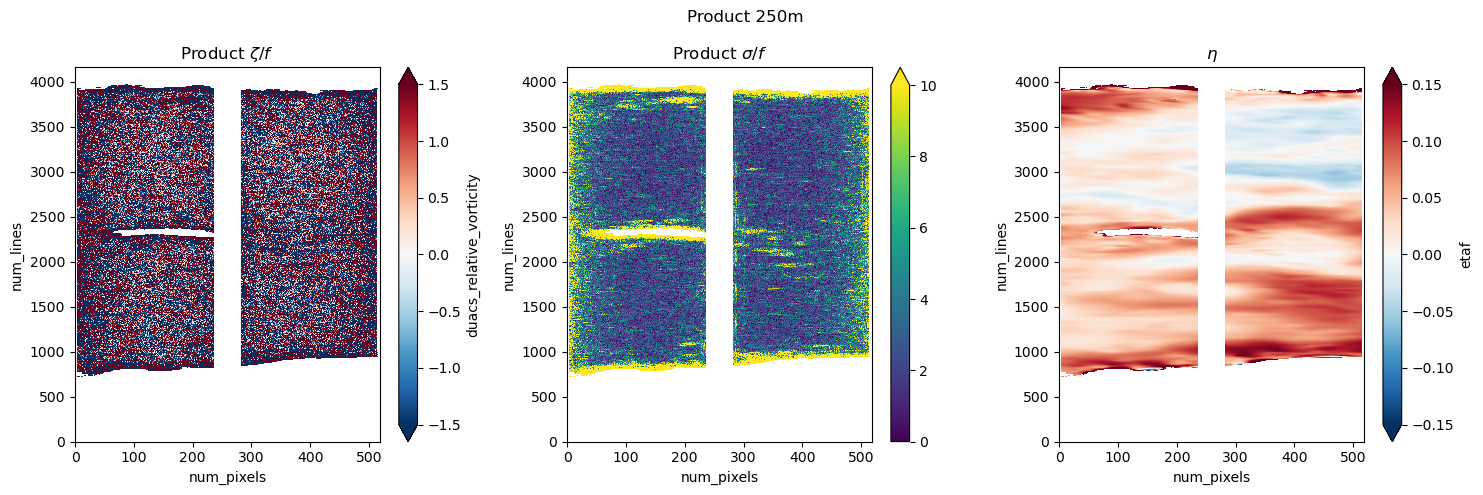

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
dss.duacs_relative_vorticity.plot(vmin=-1.5, vmax=1.5, cmap = 'RdBu_r', ax=axs[0])
axs[0].set_title(r'Product $\zeta/f$')
(dss.duacs_strain/dss.f).plot(vmax=10, ax=axs[1])
axs[1].set_title(r'Product $\sigma/f$')
dss.etaf.plot(ax=axs[2], vmax=0.15)
axs[2].set_title(r'$\eta$')
fig.suptitle('Product 250m')
fig.tight_layout()

___________
# Naive computation

In [15]:
ggd_variables = ['cvl_mean_dynamic_topography_cnes_cls_22',
                 'cvl_mean_sea_surface_cnes_22_hybrid',
                 'cvl_ocean_tide_fes_2022',
                 'cvl_ssha_reference',
                 'duacs_ssha_karin_2_calibrated',
                 'duacs_ssha_karin_2_filtered',]

def secondderivative_naive(dss, cutoff, ggd_variables=None, **kwargs):
    g=9.81
    if ggd_variables : dss_ggd = dss[ggd_variables]
    
    dx = float(dss_ggd.dx.mean())
    dy = float(dss_ggd.dy.mean())

    dss_ggdx = xr.Dataset()
    dss_ggdy = xr.Dataset()
    
    dx = dss_ggd.dx.mean() # meters
    dy = dss_ggd.dy.mean()
    
    dss_ggdx = (g*dss_ggd.differentiate("num_pixels")/dx).rename({v:'ggdx_'+v for v in ggd_variables})#.where(~dss['duacs_ssha_karin_2_filtered'].isnull())
    dss_ggdy = (g*dss_ggd.differentiate("num_lines")/dy).rename({v:'ggdy_'+v for v in ggd_variables})#.where(~dss['duacs_ssha_karin_2_filtered'].isnull())

    dss_ggdxx = (dss_ggdx.differentiate("num_pixels")/dx).rename({'ggdx_'+v:'ggdxx_'+v for v in ggd_variables})
    dss_ggdyy = (dss_ggdy.differentiate("num_lines")/dy).rename({'ggdy_'+v:'ggdyy_'+v for v in ggd_variables})
    dss_ggdxy = (dss_ggdx.differentiate("num_lines")/dy).rename({'ggdx_'+v:'ggdxy_'+v for v in ggd_variables})
    
    return xr.merge([dss_ggdx, dss_ggdy, dss_ggdxx, dss_ggdyy, dss_ggdxy]).where(~dss['duacs_ssha_karin_2_filtered'].isnull())

def strain_vorticity(dsg) : 
    dsg['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dsg.latitude * np.pi / 180)
    dsg['vorticity'] = (dsg['ggdxx_duacs_ssha_karin_2_filtered'] 
                        + dsg['ggdxx_cvl_mean_dynamic_topography_cnes_cls_22']
                        + dsg['ggdxx_cvl_ocean_tide_fes_2022']
                        + dsg['ggdyy_duacs_ssha_karin_2_filtered']
                        + dsg['ggdyy_cvl_mean_dynamic_topography_cnes_cls_22']
                        + dsg['ggdyy_cvl_ocean_tide_fes_2022'])/dsg['f']
    
    dsg['sigma_s'] = (dsg['ggdxx_duacs_ssha_karin_2_filtered'] 
                        + dsg['ggdxx_cvl_mean_dynamic_topography_cnes_cls_22']
                        + dsg['ggdxx_cvl_mean_dynamic_topography_cnes_cls_22']
                        - dsg['ggdyy_duacs_ssha_karin_2_filtered']
                        - dsg['ggdyy_cvl_mean_dynamic_topography_cnes_cls_22']
                        - dsg['ggdyy_cvl_ocean_tide_fes_2022'])/dsg['f']
    
    dsg['sigma_n'] = -2*(dsg['ggdxy_duacs_ssha_karin_2_filtered'] 
                        + dsg['ggdxy_cvl_mean_dynamic_topography_cnes_cls_22']
                        + dsg['ggdxy_cvl_ocean_tide_fes_2022'])/dsg['f']



In [16]:
dsg = secondderivative_naive(dss, '', ggd_variables)
strain_vorticity(dsg) 
dsg#.rename({'ggdx_'+v:'ggdxx_'+v for v in dss})

<xarray.Dataset> Size: 674MB
Dimensions:                                        (num_lines: 4161,
                                                    num_pixels: 519)
Coordinates:
    latitude                                       (num_lines, num_pixels) float64 17MB ...
    longitude                                      (num_lines, num_pixels) float64 17MB ...
    dx                                             (num_lines, num_pixels) float64 17MB ...
    phi                                            (num_lines, num_pixels) float64 17MB ...
    dy                                             (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/34)
    ggdx_cvl_mean_dynamic_topography_cnes_cls_22   (num_lines, num_pixels) float64 17MB ...
    ggdx_cvl_mean_sea_surface_cnes_22_hybrid       (num_lines, num_pixels) float64 17MB ...
    ggdx_cvl_ocean_tide_fes_2022                   (num_lines, num_pixels) float64 17MB ...
    ggdx_cvl_ssha_reference                        (num_lines, num_pixels) float64 17MB ...
    ggdx_duacs_ssha_karin_2_calibrated             (num_lines, num_pixels) float64 17MB ...
    ggdx_duacs_ssha_karin_2_filtered               (num_lines, num_pixels) float64 17MB ...
    ...                                             ...
    ggdxy_duacs_ssha_karin_2_calibrated            (num_lines, num_pixels) float64 17MB ...
    ggdxy_duacs_ssha_karin_2_filtered              (num_lines, num_pixels) float64 17MB ...
    f                                              (num_lines, num_pixels) float64 17MB ...
    vorticity                                      (num_lines, num_pixels) float64 17MB ...
    sigma_s                                        (num_lines, num_pixels) float64 17MB ...
    sigma_n                                        (num_lines, num_pixels) float64 17MB ...

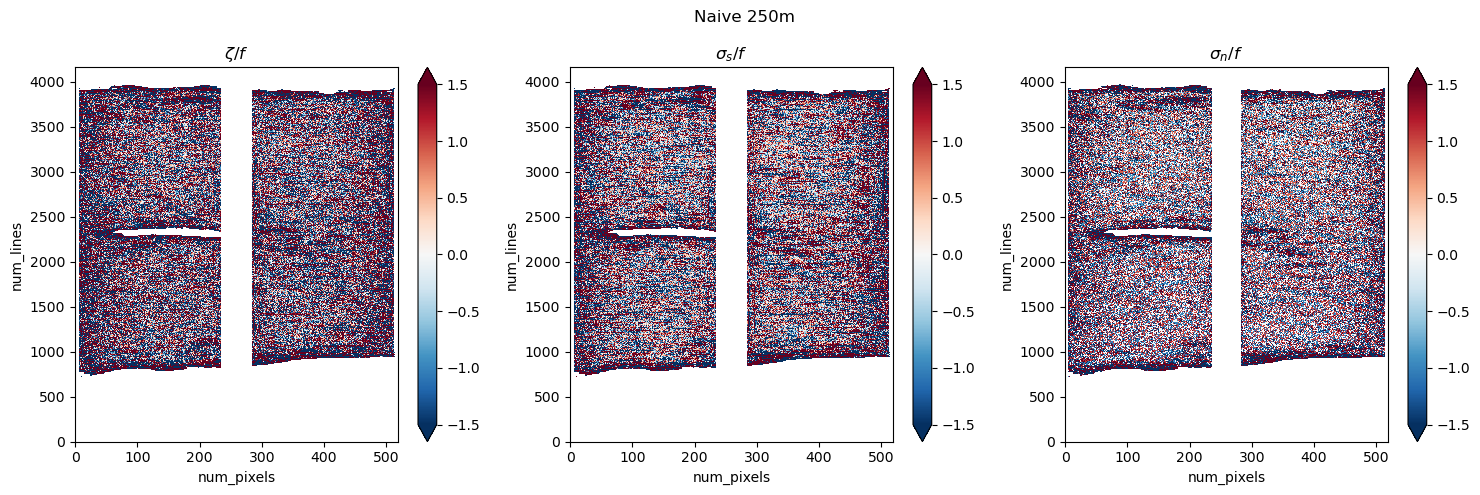

In [29]:
fig, axs = plt.subplots(1,3, figsize=(15, 5))
axs =axs.flatten()

ax = axs[0]
(dsg.vorticity/dsg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\zeta/f$')

ax = axs[1]
(dsg.sigma_s/dsg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\sigma_s/f$')

ax = axs[2]
(dsg.sigma_n/dsg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\sigma_n/f$')
fig.suptitle('Naive 250m')
fig.tight_layout()

________
# Gaussian filter

In [26]:
def secondderivative_gauss(dss, cutoff, ggd_variables=None, **kwargs):
    g=9.81
    # gaussian derivative
    from scipy.ndimage import gaussian_filter

    if ggd_variables : dss_ggd = dss[ggd_variables]
    else : dss_ggd = dss
    
    dx = float(dss_ggd.dx.mean())
    dy = float(dss_ggd.dy.mean())

    dss_ggdx = xr.Dataset()
    dss_ggdy = xr.Dataset()
    dss_ggdxx = xr.Dataset()
    dss_ggdyy = xr.Dataset()
    dss_ggdxy = xr.Dataset()
    
    
    for v in dss_ggd : 
        da = dss_ggd[v].interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines')# prevent nan to spread
        
        # cross-track
        i = da.get_axis_num("num_pixels")
        order = [0,0]
        order[i] = 1
        dss_ggdx['ggdx_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dx, order=order, **kwargs), dims=da.dims)/dx)
        dss_ggdx['ggdxx_'+v] = (xr.DataArray(gaussian_filter(dss_ggdx['ggdx_'+v], sigma=cutoff/dx, order=order, **kwargs), dims=da.dims)/dx)

        
        # along-track
        i = da.get_axis_num("num_lines")
        order = [0,0]
        order[i] = 1
        dss_ggdy['ggdy_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dy, order=order, **kwargs), dims=da.dims)/dy)
        dss_ggdyy['ggdyy_'+v] =(xr.DataArray(gaussian_filter(dss_ggdy['ggdy_'+v], sigma=cutoff/dy, order=order, **kwargs), dims=da.dims)/dy)
        dss_ggdxy['ggdxy_'+v] = (xr.DataArray(gaussian_filter(dss_ggdx['ggdx_'+v], sigma=cutoff/dy, order=order, **kwargs), dims=da.dims)/dy)
              
    return xr.merge([dss_ggdx, dss_ggdy, dss_ggdxx, dss_ggdyy, dss_ggdxy]).where(~dss['duacs_ssha_karin_2_filtered'].isnull())



In [27]:
cutoff = 2e3
dsgg = secondderivative_gauss(dss, cutoff, ggd_variables)
strain_vorticity(dsgg) 
dsgg

<xarray.Dataset> Size: 674MB
Dimensions:                                        (num_lines: 4161,
                                                    num_pixels: 519)
Coordinates:
    latitude                                       (num_lines, num_pixels) float64 17MB ...
    longitude                                      (num_lines, num_pixels) float64 17MB ...
    dx                                             (num_lines, num_pixels) float64 17MB ...
    phi                                            (num_lines, num_pixels) float64 17MB ...
    dy                                             (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/34)
    ggdx_cvl_mean_dynamic_topography_cnes_cls_22   (num_lines, num_pixels) float64 17MB ...
    ggdxx_cvl_mean_dynamic_topography_cnes_cls_22  (num_lines, num_pixels) float64 17MB ...
    ggdx_cvl_mean_sea_surface_cnes_22_hybrid       (num_lines, num_pixels) float64 17MB ...
    ggdxx_cvl_mean_sea_surface_cnes_22_hybrid      (num_lines, num_pixels) float64 17MB ...
    ggdx_cvl_ocean_tide_fes_2022                   (num_lines, num_pixels) float64 17MB ...
    ggdxx_cvl_ocean_tide_fes_2022                  (num_lines, num_pixels) float64 17MB ...
    ...                                             ...
    ggdxy_duacs_ssha_karin_2_calibrated            (num_lines, num_pixels) float64 17MB ...
    ggdxy_duacs_ssha_karin_2_filtered              (num_lines, num_pixels) float64 17MB ...
    f                                              (num_lines, num_pixels) float64 17MB ...
    vorticity                                      (num_lines, num_pixels) float64 17MB ...
    sigma_s                                        (num_lines, num_pixels) float64 17MB ...
    sigma_n                                        (num_lines, num_pixels) float64 17MB ...

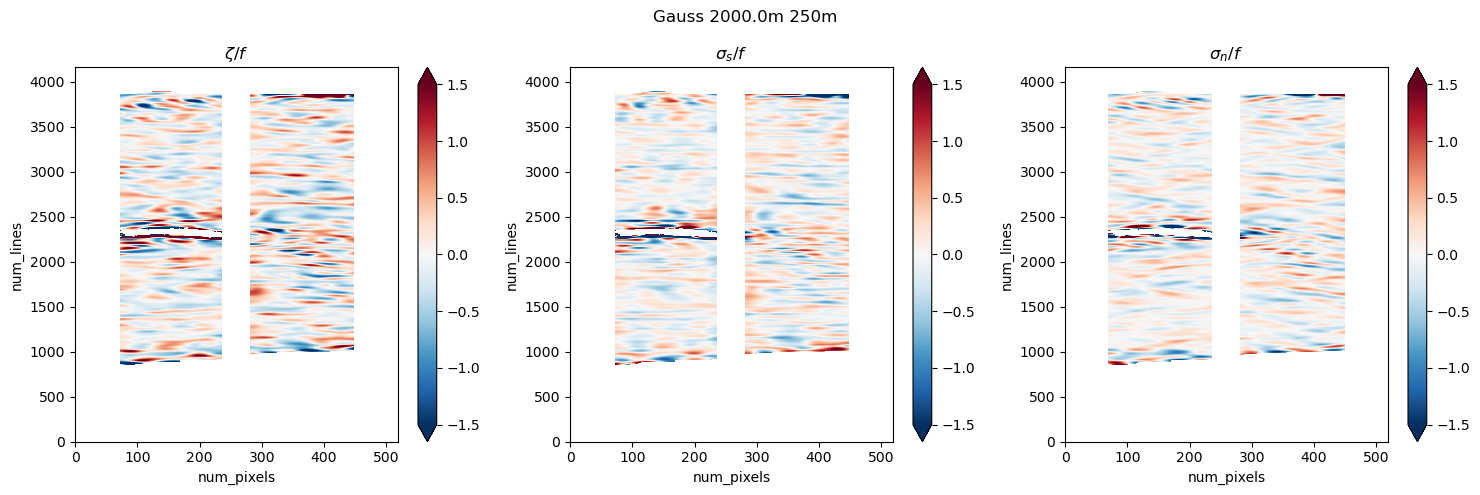

In [30]:
fig, axs = plt.subplots(1,3, figsize=(15, 5))
axs =axs.flatten()

ax = axs[0]
(dsgg.vorticity/dsgg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\zeta/f$')

ax = axs[1]
(dsgg.sigma_s/dsgg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\sigma_s/f$')

ax = axs[2]
(dsgg.sigma_n/dsgg.f).plot(vmax = 1.5, ax=ax)
ax.set_title(r'$\sigma_n/f$')
fig.suptitle(f'Gauss {cutoff}m 250m')
fig.tight_layout()